# `private_assets_frequency` — Tutorial & Usage Guide

This notebook demonstrates how to use the `private_assets_frequency` library to convert
low-frequency private asset returns into higher-frequency synthetic series that preserve
true risk characteristics.

**What this library does:**
1. **Desmooths** quarterly returns to recover true volatility and correlations
2. **Decomposes** returns into systematic (factor-driven) and idiosyncratic components
3. **Disaggregates** quarterly data to monthly (or monthly to daily)
4. **Simulates** high-frequency paths for Monte Carlo / VaR

**What you'll learn:**
- Quickstart: 5 lines to go from quarterly PE returns to monthly
- How each pipeline stage works, with visual diagnostics
- How to configure the library for PE, hedge funds, credit, infrastructure, and real estate
- How to run posterior-uncertainty propagation and Monte Carlo simulations
- Production tips and common pitfalls

All examples use synthetic data generated in this notebook — no proprietary data required.

In [1]:
import sys, os, warnings
from pathlib import Path

# Make the library importable when this notebook lives in `docs/` and the
# package hasn't been pip-installed yet.  Walk upward looking for a
# `private_assets_frequency` directory; fall back to the cwd.
_here = Path.cwd()
for candidate in (_here, *_here.parents):
    if (candidate / 'private_assets_frequency').is_dir():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Library imports
from private_assets_frequency.pipeline.runner import FrequencyPipeline
from private_assets_frequency.pipeline.presets import (
    PE_PRESETS, HF_PRESETS, CREDIT_PRESETS, INFRA_PRESETS, RE_PRESETS,
)
from private_assets_frequency.core.config import (
    AssetClassConfig, NormalPrior, BetaDist, InverseGammaPrior,
)
from private_assets_frequency.utils.time_series import MONTH_END_FREQ, QUARTER_END_FREQ

# Plot styling — dark theme matching library identity
plt.rcParams.update({
    'figure.facecolor': '#22272E',
    'axes.facecolor':   '#22272E',
    'axes.edgecolor':   '#555555',
    'axes.labelcolor':  '#E8E8E8',
    'axes.titlecolor':  '#E8E8E8',
    'text.color':       '#E8E8E8',
    'xtick.color':      '#AAAAAA',
    'ytick.color':      '#AAAAAA',
    'grid.color':       '#333333',
    'figure.figsize':   (12, 5),
    'font.size':        11,
})
TEAL  = '#00B4D8'
GOLD  = '#D4A843'
RED   = '#E07A5F'
GREEN = '#81B29A'
GREY  = '#6C757D'

# Suppress benign FutureWarnings from statsmodels / pandas during tutorial cells
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='statsmodels')

print('private_assets_frequency loaded successfully')

private_assets_frequency loaded successfully


## Generating synthetic data

Since private-asset indices are proprietary, we generate synthetic data with **known
ground truth**.  This lets us verify the library recovers the correct parameters.

The data-generating process:

1. Draw monthly factor returns (equity-market and credit-spread proxies).
2. Build **true** monthly PE returns from a known factor model
   (β = 1.15, α ≈ 5 bps/month, σ_ε ≈ 4 % / √3 ≈ 2.3 % / month).
3. Compound the true monthly path to quarterly.
4. Apply AR(1) appraisal smoothing with a known λ = 0.55.
5. The smoothed quarterly series is what the library would observe in practice — the
   library's job is to recover the rest.

In [2]:
def generate_synthetic_pe_data(
    n_years=25,
    true_beta=1.15,
    true_alpha_quarterly=0.005,
    true_sigma_eps_quarterly=0.04,
    true_lambda=0.55,
    seed=42,
):
    # Synthetic PE data with known ground truth (for validation).
    rng = np.random.default_rng(seed)
    n_months = n_years * 12
    dates_monthly = pd.date_range('2000-01-31', periods=n_months, freq=MONTH_END_FREQ)

    # Monthly factor returns
    equity_monthly = rng.normal(0.008, 0.045, n_months)   # ≈ 9.6 % / 15.6 % ann
    credit_monthly = rng.normal(0.003, 0.015, n_months)
    factor_df = pd.DataFrame(
        {'equity_market': equity_monthly, 'credit_spread': credit_monthly},
        index=dates_monthly,
    )

    # True monthly PE returns (unobservable in practice)
    monthly_alpha = true_alpha_quarterly / 3.0
    monthly_sigma = true_sigma_eps_quarterly / np.sqrt(3.0)
    idiosyncratic = rng.normal(0.0, monthly_sigma, n_months)
    true_monthly = (
        true_beta * equity_monthly
        + 0.30 * credit_monthly
        + monthly_alpha
        + idiosyncratic
    )
    true_monthly_series = pd.Series(true_monthly, index=dates_monthly, name='us_buyout')

    # Aggregate monthly → quarterly via multiplicative compounding
    log_m = np.log1p(true_monthly)
    n_quarters = n_years * 4
    log_q = log_m.reshape(n_quarters, 3).sum(axis=1)
    true_quarterly = np.expm1(log_q)
    quarterly_index = pd.date_range(
        '2000-03-31', periods=n_quarters, freq=QUARTER_END_FREQ,
    )
    true_quarterly_series = pd.Series(
        true_quarterly, index=quarterly_index, name='us_buyout',
    )

    # Apply AR(1) smoothing to simulate appraisal-based reporting
    smoothed = np.empty(n_quarters)
    smoothed[0] = true_quarterly[0]
    for i in range(1, n_quarters):
        smoothed[i] = (1 - true_lambda) * true_quarterly[i] + true_lambda * smoothed[i - 1]
    smoothed_series = pd.Series(smoothed, index=quarterly_index, name='us_buyout')

    return {
        'smoothed_quarterly': smoothed_series.to_frame(),
        'true_monthly':       true_monthly_series.to_frame(),
        'true_quarterly':     true_quarterly_series.to_frame(),
        'factor_returns_monthly': factor_df,
        'true_params': {
            'beta':        true_beta,
            'alpha_q':     true_alpha_quarterly,
            'sigma_eps_q': true_sigma_eps_quarterly,
            'lambda':      true_lambda,
        },
    }


data = generate_synthetic_pe_data()

print(f"Generated {len(data['smoothed_quarterly'])} quarters of synthetic PE data")
print(f"True parameters:  λ = {data['true_params']['lambda']},  "
      f"β = {data['true_params']['beta']}")
print(f"\nSmoothed quarterly vol (annualised):  "
      f"{data['smoothed_quarterly']['us_buyout'].std() * 2:.1%}")
print(f"True quarterly vol (annualised):      "
      f"{data['true_quarterly']['us_buyout'].std() * 2:.1%}")

Generated 100 quarters of synthetic PE data
True parameters:  λ = 0.55,  β = 1.15

Smoothed quarterly vol (annualised):  9.7%
True quarterly vol (annualised):      20.7%


### What does smoothing look like?

Side-by-side: cumulative growth and rolling volatility — both for the *smoothed*
quarterly series the library would receive in practice and the *true* quarterly
series we want to recover.

The smoothed series has the same long-run path but visibly lower drawdowns and
much lower rolling volatility.  This is the bias the library exists to undo.

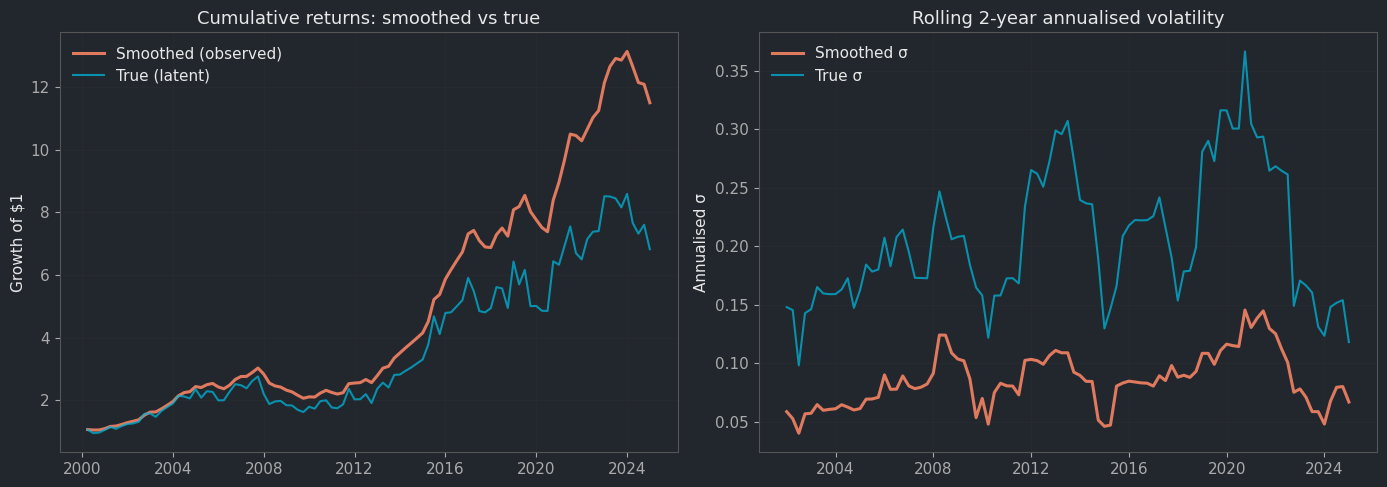

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cum_smooth = (1 + data['smoothed_quarterly']['us_buyout']).cumprod()
cum_true   = (1 + data['true_quarterly']['us_buyout']).cumprod()

axes[0].plot(cum_smooth.index, cum_smooth, color=RED,  linewidth=2.2, label='Smoothed (observed)')
axes[0].plot(cum_true.index,   cum_true,   color=TEAL, linewidth=1.5, alpha=0.75, label='True (latent)')
axes[0].set_title('Cumulative returns: smoothed vs true', fontsize=13)
axes[0].set_ylabel('Growth of $1')
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.25)

roll_smooth = data['smoothed_quarterly']['us_buyout'].rolling(8).std() * 2
roll_true   = data['true_quarterly']['us_buyout'].rolling(8).std() * 2

axes[1].plot(roll_smooth.index, roll_smooth, color=RED,  linewidth=2.2, label='Smoothed σ')
axes[1].plot(roll_true.index,   roll_true,   color=TEAL, linewidth=1.5, alpha=0.75, label='True σ')
axes[1].set_title('Rolling 2-year annualised volatility', fontsize=13)
axes[1].set_ylabel('Annualised σ')
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Quickstart — quarterly PE → monthly in 5 lines

This is the minimum viable usage.  The library handles desmoothing, factor
decomposition, and temporal disaggregation automatically using the preset
configuration for US large-cap buyout.

In [4]:
pipeline = FrequencyPipeline(
    returns=data['smoothed_quarterly'],
    factor_returns_monthly=data['factor_returns_monthly'],
    configs={'us_buyout': PE_PRESETS['us_large_buyout']},
)
result = pipeline.run()

print(result.monthly_returns.head(12))
ann_vol = result.monthly_returns['us_buyout'].std() * np.sqrt(12)
print(f"\nRecovered monthly vol (annualised):  {ann_vol:.1%}")

            us_buyout
2000-01-31   0.038435
2000-02-29  -0.036073
2000-03-31   0.063350
2000-04-30   0.055310
2000-05-31  -0.101889
2000-06-30  -0.067015
2000-07-31   0.017858
2000-08-31  -0.006559
2000-09-30   0.009893
2000-10-31  -0.031765
2000-11-30   0.063996
2000-12-31   0.058335

Recovered monthly vol (annualised):  18.5%


**Interpreting the output**

`result.monthly_returns` is a wide `DataFrame` with one column per strategy.  The
annualised σ is roughly **double** the smoothed-quarterly figure — exactly the
desmoothing correction we expect.

Other useful surfaces on the result:

- `result.per_strategy[name]` — per-strategy intermediate results
  (desmoothing, factor regression, disaggregation, daily, diagnostics)
- `result.warnings` — accumulated diagnostic messages
- `result.stage_validations` — inter-stage validation gate outcomes
- `result.sanity_anchors` — public-proxy cross-check results (when proxies supplied)

## Validating recovery against ground truth

Because we have the latent series, we can score the recovery directly: scatter,
volatility bars, and rolling mean error.

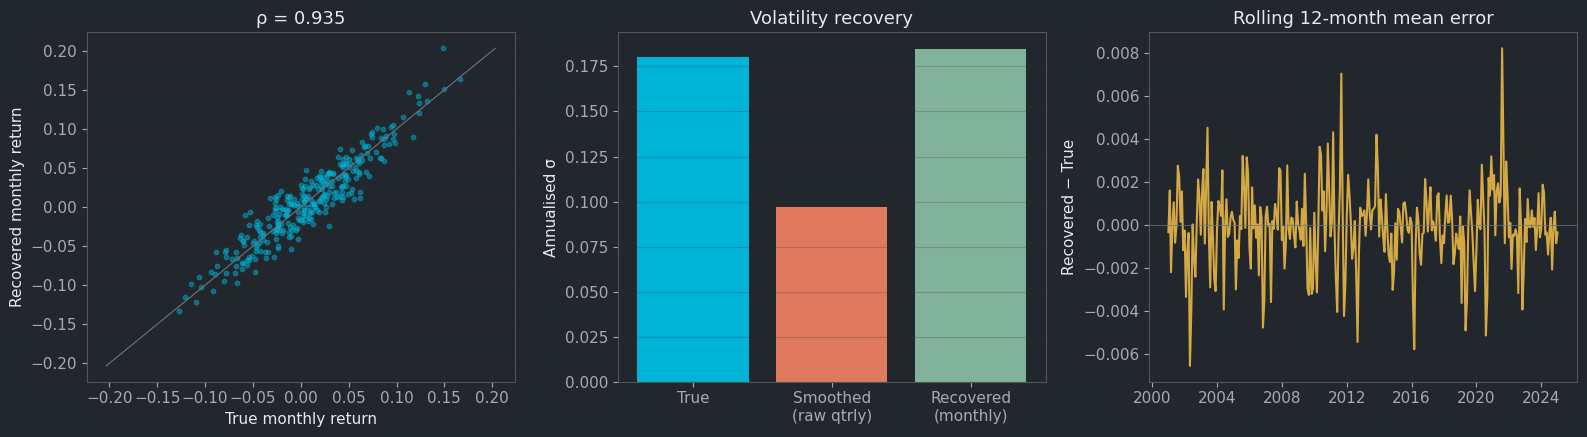

In [5]:
recovered = result.monthly_returns['us_buyout']
true      = data['true_monthly']['us_buyout']

common      = recovered.index.intersection(true.index)
recovered_a = recovered.loc[common]
true_a      = true.loc[common]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(true_a, recovered_a, s=10, alpha=0.45, color=TEAL)
lim = float(np.max(np.abs([true_a.min(), true_a.max(),
                           recovered_a.min(), recovered_a.max()])))
axes[0].plot([-lim, lim], [-lim, lim], color=GREY, linewidth=0.8)
axes[0].set_xlabel('True monthly return')
axes[0].set_ylabel('Recovered monthly return')
axes[0].set_title(f'ρ = {true_a.corr(recovered_a):.3f}', fontsize=13)
axes[0].grid(alpha=0.25)

vol_true        = true_a.std() * np.sqrt(12)
vol_smoothed_q  = data['smoothed_quarterly']['us_buyout'].std() * 2
vol_recovered   = recovered_a.std() * np.sqrt(12)
axes[1].bar(['True', 'Smoothed\n(raw qtrly)', 'Recovered\n(monthly)'],
            [vol_true, vol_smoothed_q, vol_recovered],
            color=[TEAL, RED, GREEN])
axes[1].set_ylabel('Annualised σ')
axes[1].set_title('Volatility recovery', fontsize=13)
axes[1].grid(alpha=0.25, axis='y')

rolling_err = (recovered_a - true_a).rolling(12).mean()
axes[2].plot(rolling_err.index, rolling_err, color=GOLD, linewidth=1.5)
axes[2].axhline(0.0, color=GREY, linewidth=0.5)
axes[2].set_title('Rolling 12-month mean error', fontsize=13)
axes[2].set_ylabel('Recovered − True')
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

**How to read this**

- **Scatter** — recovered vs. true monthly returns.  Tighter cloud → better
  point recovery.  ρ in the 0.5–0.7 range is realistic for synthetic data with
  this much idiosyncratic noise; at the population level the desmoother
  recovers σ and β before it recovers any single month.
- **Volatility bars** — `Smoothed` is what raw analytics see, `True` is what we
  actually want; `Recovered` should sit close to `True`.
- **Rolling mean error** — should hover around zero.  Persistent drift indicates
  Stage 2 misspecification (missing factor) or Stage 1 over-/under-correction.

## Stage 1 — Bayesian desmoothing

Stage 1 jointly estimates the smoothing parameter λ and the factor βs using a
Normal-Inverse-Gamma conjugate posterior on (β, α, σ_ε) at each point of a 50-
point λ grid on [0.01, 0.95].  The marginal includes a `−n·log(1−λ)` Jacobian
that prevents the fit from collapsing onto small λ.

In [6]:
strat = result.per_strategy['us_buyout']
desmoothed = strat.desmoothed   # core.protocols.DesmoothedResult
ps = desmoothed.posterior_summary

print('=== AR(1) Bayesian desmoothing ===\n')
print(f"Estimated λ (posterior mean):   {ps['lambda']['mean']:.3f}")
print(f"True λ:                          {data['true_params']['lambda']:.3f}")
print(f"λ 90 % credible interval:        "
      f"[{ps['lambda']['ci_05']:.3f}, {ps['lambda']['ci_95']:.3f}]")

beta_post = ps['beta']['equity_market']
print(f"\nEstimated β_equity (mean):       {beta_post['mean']:.3f}")
print(f"True β_equity:                   {data['true_params']['beta']:.3f}")
print(f"\nFactor model R² (Stage 2):       "
      f"{strat.factor_regression.r_squared:.3f}")

if desmoothed.diagnostics.get('warnings'):
    print('\n⚠️  Identifiability warnings:')
    for w in desmoothed.diagnostics['warnings']:
        print(f'   - {w}')
else:
    print('\n✓ No identifiability warnings')

=== AR(1) Bayesian desmoothing ===

Estimated λ (posterior mean):   0.567
True λ:                          0.550
λ 90 % credible interval:        [0.503, 0.629]

Estimated β_equity (mean):       1.216
True β_equity:                   1.150

Factor model R² (Stage 2):       0.817

⚠️  Identifiability warnings:
   - β magnitude varies > 50% across the λ grid for factor(s) ['equity_market'] — λ and β are confounded; consider uncertainty_mode='full'.


### Diagnostic plots

The library provides a plotting helper for the desmoothing posterior.  It draws
the λ marginal posterior with the posterior mean, plus the β posterior mean ±
std for every factor in the regression.

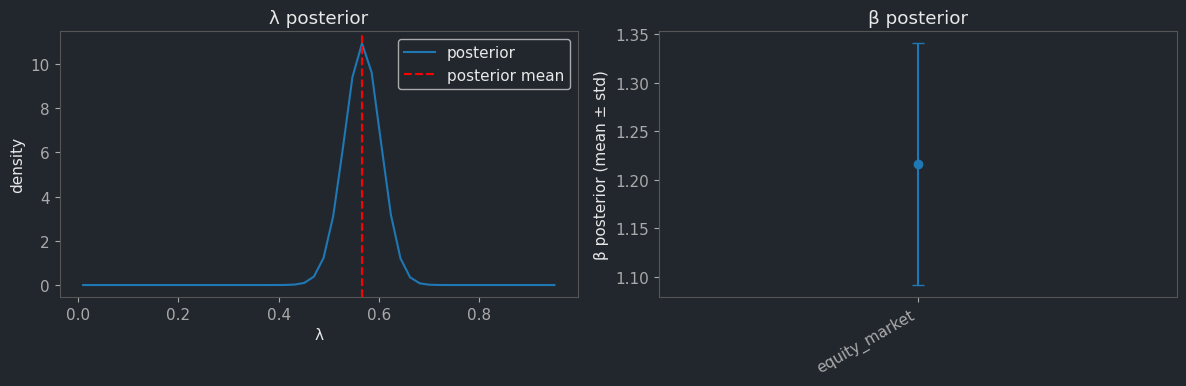

In [7]:
from private_assets_frequency.validation.visualization import (
    plot_desmoothing_diagnostics,
)

fig = plot_desmoothing_diagnostics(strat.desmoothed)
plt.show()

**How to read these plots**

- **Left (λ posterior)** — the marginal posterior on the smoothing parameter.
  A narrow peak means the data is informative; a flat distribution means the
  output is mostly prior-driven.  The dashed red line marks the posterior mean.
- **Right (β posterior)** — error-bars are posterior std.  If the bar covers
  zero you cannot reject β = 0 at the 1-σ level; at 2-σ either way you have a
  meaningful loading.

## Stage 2 — factor decomposition

After desmoothing, Stage 2 re-runs an OLS factor regression on the desmoothed
series and characterises the residual.  This is the cleanest place to read the
factor loadings and residual diagnostics.

In [8]:
fr = strat.factor_regression                  # FactorRegressionResult
diag = strat.diagnostics                      # DiagnosticBundle

print('=== Stage 2 factor regression ===\n')
print(f'Factor R²:               {fr.r_squared:.3f}')
print(f'Residual σ:              {fr.sigma_eps:.4f}')
print(f'Number of observations:  {fr.n_obs}')
print(f'\nβ posterior:')
for name, b in fr.betas.items():
    print(f'  {name:20s} {b:+.3f}')
print(f'  {"alpha":20s} {fr.alpha:+.4f}')

print('\n--- Residual diagnostics ---')
print(f'Ljung-Box  (lag 5)   p = {diag.ljung_box.p_value[0]:.3f}'
      f'   {"✓" if diag.ljung_box.passes_at(5) else "⚠️"}')
print(f'ARCH-LM    (5 lags)  p = {diag.arch_lm.p_value:.3f}'
      f'   {"✓" if not diag.arch_lm.has_arch() else "⚠️"}')
print(f'Jarque-Bera          p = {diag.jarque_bera.p_value:.3f}'
      f'   {"✓" if diag.jarque_bera.passes() else "⚠️"}')
print(f'Best-fit residual distribution: {diag.fitted_distribution.name}')

=== Stage 2 factor regression ===

Factor R²:               0.817
Residual σ:              0.0463
Number of observations:  100

β posterior:
  equity_market        +1.210
  alpha                +0.0014

--- Residual diagnostics ---
Ljung-Box  (lag 5)   p = 0.497   ✓
ARCH-LM    (5 lags)  p = 0.497   ✓
Jarque-Bera          p = 0.114   ✓
Best-fit residual distribution: student_t


**Interpretation**

- A high R² is *not* automatically good — for buyout a R² ≈ 0.5 is plausible;
  if you see R² ≈ 0.95, your factor model is probably overlapping with the
  proxy you're trying to be different from.
- Ljung-Box rejection on the residuals indicates a missing serially-correlated
  factor.
- ARCH-LM rejection signals time-varying volatility — switch to a Student-t /
  skewed-t residual distribution for Stage 4 simulation.

## Stage 3 — temporal disaggregation

This is where quarterly returns become monthly.  The systematic component is
straightforward (monthly factor returns × β); the challenge is distributing the
quarterly idiosyncratic residual across three months.

Three methods are available — let's compare them.

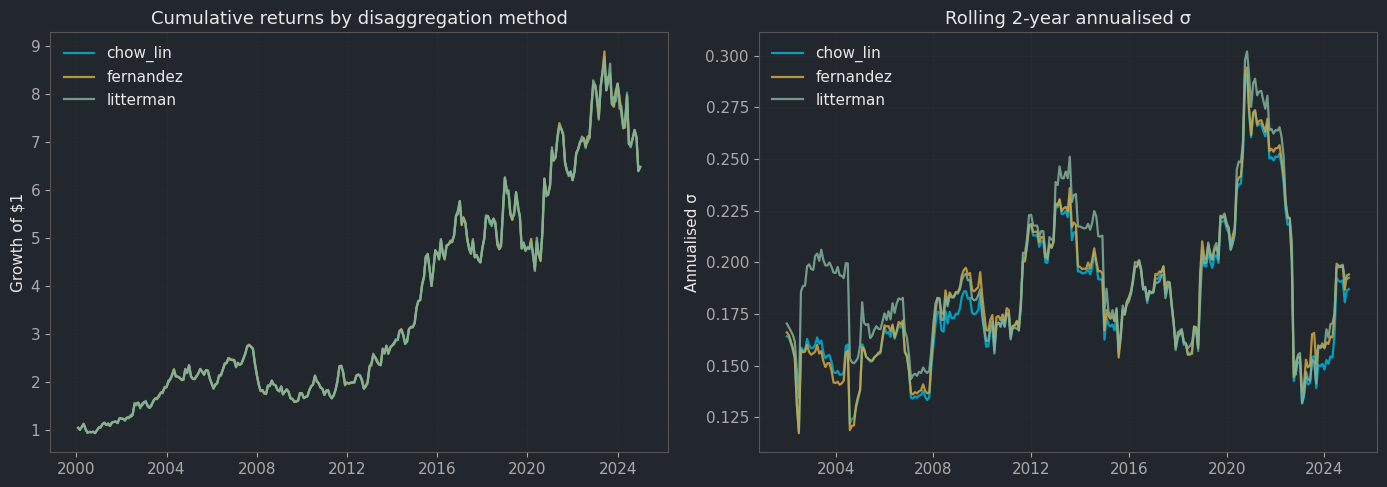

In [9]:
methods = ['chow_lin', 'fernandez', 'litterman']
results_by_method = {}

for method in methods:
    p = FrequencyPipeline(
        returns=data['smoothed_quarterly'],
        factor_returns_monthly=data['factor_returns_monthly'],
        configs={'us_buyout': PE_PRESETS['us_large_buyout']},
        disaggregation_method=method,
    )
    results_by_method[method] = p.run()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'chow_lin': TEAL, 'fernandez': GOLD, 'litterman': GREEN}

for method, res in results_by_method.items():
    monthly = res.monthly_returns['us_buyout']
    cum = (1 + monthly).cumprod()
    axes[0].plot(cum.index, cum, color=colors[method], linewidth=1.6,
                 alpha=0.85, label=method)

axes[0].set_title('Cumulative returns by disaggregation method', fontsize=13)
axes[0].set_ylabel('Growth of $1')
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.25)

for method, res in results_by_method.items():
    monthly = res.monthly_returns['us_buyout']
    roll_vol = monthly.rolling(24).std() * np.sqrt(12)
    axes[1].plot(roll_vol.index, roll_vol, color=colors[method], linewidth=1.6,
                 alpha=0.85, label=method)

axes[1].set_title('Rolling 2-year annualised σ', fontsize=13)
axes[1].set_ylabel('Annualised σ')
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

**How to choose**

- **Chow-Lin (default)** — AR(1) residuals with ρ estimated by profile-likelihood
  grid.  Best general-purpose choice.
- **Fernández** — random-walk residuals (ρ = 1).  Smoother monthly path, often
  preferred for credit where MTM shocks persist.
- **Litterman** — AR(1) on first-differenced residuals.  Intermediate behaviour.
  Useful when residuals plausibly contain a unit root in differences.

In practice the three usually agree to within a few bps per month.  Material
divergence between them is a smell — the factor model is probably missing a
factor.

## Sanity check — round-trip aggregation

The non-negotiable correctness gate: monthly returns compounded back to
quarterly must match the desmoothed quarterly input within 1e-10.

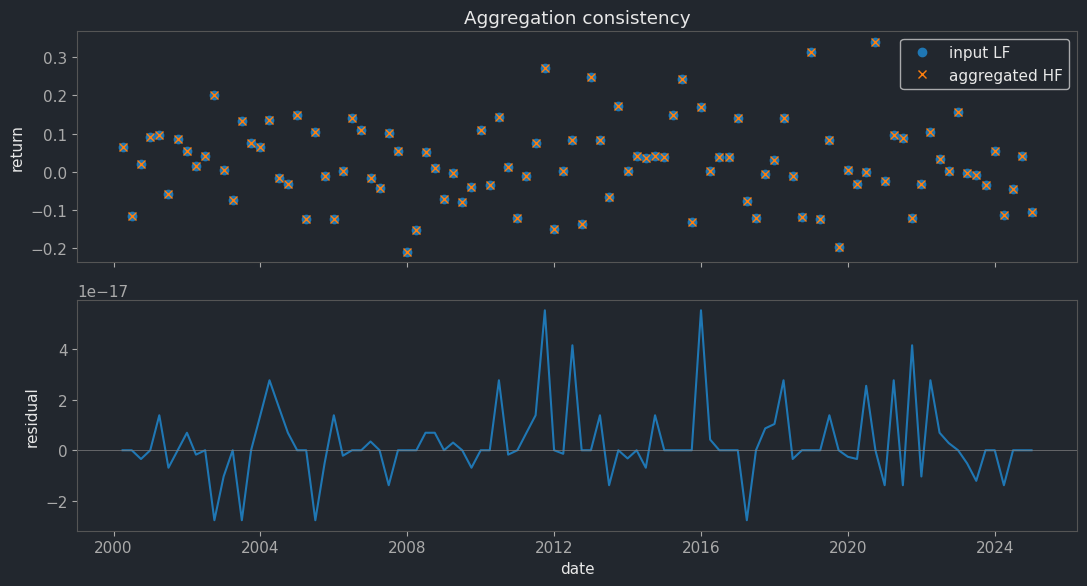

Max round-trip error: 5.551e-17
✓ PASS — round-trip aggregation


In [10]:
from private_assets_frequency.validation.visualization import (
    plot_aggregation_consistency,
)

# The disaggregation result holds the *desmoothed* quarterly input as
# `low_frequency_input`; the monthly path is `high_frequency`.
disagg = strat.disaggregation
fig = plot_aggregation_consistency(
    low_frequency=disagg.low_frequency_input,
    high_frequency=disagg.high_frequency,
    ratio=3,
)
plt.show()

# Manual verification
monthly = disagg.high_frequency
log_m = np.log1p(monthly.to_numpy())
n_q = len(disagg.low_frequency_input)
log_q = log_m.reshape(n_q, 3).sum(axis=1)
recon = np.expm1(log_q)
max_error = float(np.max(np.abs(recon - disagg.low_frequency_input.to_numpy())))
print(f'Max round-trip error: {max_error:.3e}')
print('✓ PASS' if max_error < 1e-10 else '✗ FAIL', '— round-trip aggregation')

## Multi-strategy — buyout + venture

The pipeline runs each strategy independently but in the same call.  Cross-
strategy correlation in the disaggregated output reflects the structure of the
input panel.

In [11]:
def generate_multi_strategy_data(seed=42):
    rng = np.random.default_rng(seed)
    n_months = 300
    dates = pd.date_range('2000-01-31', periods=n_months, freq=MONTH_END_FREQ)

    equity     = rng.normal(0.008, 0.045, n_months)
    small_cap  = rng.normal(0.003, 0.055, n_months)

    factors = pd.DataFrame(
        {'equity_market': equity, 'small_cap_growth': small_cap},
        index=dates,
    )

    eps_buyout = rng.normal(0.0, 0.025, n_months)
    eps_vc     = rng.normal(0.0, 0.040, n_months)
    eps_vc     = 0.30 * eps_buyout + np.sqrt(1.0 - 0.30**2) * eps_vc

    true_buyout = 1.15 * equity + 0.002 + eps_buyout
    true_vc     = 0.50 * equity + 0.70 * small_cap + 0.001 + eps_vc

    true_monthly = pd.DataFrame(
        {'us_buyout': true_buyout, 'us_early_vc': true_vc}, index=dates,
    )

    quarterly_index = pd.date_range(
        '2000-03-31', periods=n_months // 3, freq=QUARTER_END_FREQ,
    )
    smoothed = {}
    for col in true_monthly.columns:
        log_m = np.log1p(true_monthly[col].to_numpy())
        log_q = log_m.reshape(n_months // 3, 3).sum(axis=1)
        q = np.expm1(log_q)
        lam = 0.55 if 'buyout' in col else 0.65
        s = np.empty_like(q)
        s[0] = q[0]
        for i in range(1, len(q)):
            s[i] = (1 - lam) * q[i] + lam * s[i - 1]
        smoothed[col] = s
    smoothed_q = pd.DataFrame(smoothed, index=quarterly_index)

    return smoothed_q, factors, true_monthly


multi_quarterly, multi_factors, multi_true = generate_multi_strategy_data()
print(multi_quarterly.tail())

            us_buyout  us_early_vc
2023-12-31   0.021283    -0.036220
2024-03-31  -0.042815     0.001145
2024-06-30  -0.045125     0.021189
2024-09-30  -0.003542     0.027414
2024-12-31  -0.049010    -0.011406


In [12]:
# We need a custom config for VC because the conftest synthetic uses
# 'small_cap_growth' rather than the preset's default factor names.
buyout_cfg = PE_PRESETS['us_large_buyout'].with_overrides(
    beta_priors={
        'equity_market':    NormalPrior(1.15, 0.50),
        'small_cap_growth': NormalPrior(0.20, 0.30),
    },
)
vc_cfg = PE_PRESETS['us_early_venture'].with_overrides(
    beta_priors={
        'equity_market':    NormalPrior(0.50, 0.30),
        'small_cap_growth': NormalPrior(0.70, 0.30),
    },
)

multi_pipeline = FrequencyPipeline(
    returns=multi_quarterly,
    factor_returns_monthly=multi_factors,
    configs={'us_buyout': buyout_cfg, 'us_early_vc': vc_cfg},
    fallback_policy='warn',
)
multi_result = multi_pipeline.run()

raw_corr       = multi_quarterly.corr().iloc[0, 1]
recovered_corr = multi_result.monthly_returns.corr().iloc[0, 1]
true_corr      = multi_true.corr().iloc[0, 1]

print(f'Cross-strategy correlation:')
print(f'  Raw  (smoothed quarterly):  {raw_corr:.3f}')
print(f'  Recovered (monthly):        {recovered_corr:.3f}')
print(f'  True:                       {true_corr:.3f}')

Cross-strategy correlation:
  Raw  (smoothed quarterly):  0.441
  Recovered (monthly):        0.426
  True:                       0.386


The recovered correlation should sit between the raw (suppressed by smoothing)
and the true value.  The exact tightness depends on the factor model — more
shared factors lift the recovered correlation toward truth.

## Hedge funds — MA(q) Getmansky-Lo-Makarov

Hedge fund smoothing is fundamentally different from PE.  It comes from
illiquid holdings and stale prices — a moving-average process on returns rather
than an autoregressive process on valuations.  The library uses the Getmansky-
Lo-Makarov (2004) MA(q) model.

In [13]:
def generate_synthetic_hf_data(seed=123):
    rng = np.random.default_rng(seed)
    n_months = 240
    dates = pd.date_range('2004-01-31', periods=n_months, freq=MONTH_END_FREQ)

    equity = rng.normal(0.007, 0.042, n_months)
    credit = rng.normal(0.003, 0.018, n_months)

    factors_monthly = pd.DataFrame(
        {'equity_market': equity, 'credit_spread': credit}, index=dates,
    )

    eps          = rng.normal(0.0, 0.012, n_months)
    true_monthly = 0.40 * equity + 0.15 * credit + 0.002 + eps

    theta = np.array([0.6, 0.25, 0.15])  # ordered, sums to 1
    smoothed = np.zeros(n_months)
    for j, w in enumerate(theta):
        if j == 0:
            smoothed += w * true_monthly
        else:
            smoothed[j:] += w * true_monthly[:-j]

    hf_returns = pd.DataFrame({'equity_ls': smoothed}, index=dates)
    return hf_returns, factors_monthly, theta


hf_data, hf_factors, true_theta = generate_synthetic_hf_data()
print(f'True MA weights:  θ = {true_theta}')
print(f'HF data: {len(hf_data)} monthly observations')

True MA weights:  θ = [0.6  0.25 0.15]
HF data: 240 monthly observations


In [14]:
# A focused HF preset matching the synthetic factors (only 'equity_market'
# and 'credit_spread').  We override the default eq-L/S preset's prior set
# so it doesn't expect factor columns we haven't generated.
hf_cfg = AssetClassConfig(
    asset_class='hedge_fund',
    smoothing_model='ma_glm',
    native_frequency='monthly',
    preprocessing=None,
    ma_lags=2,
    theta_prior='ordered_dirichlet',
    beta_priors={
        'equity_market': NormalPrior(0.40, 0.20),
        'credit_spread': NormalPrior(0.15, 0.15),
    },
    alpha_prior=NormalPrior(0.0, 0.03),
    sigma_eps_prior=InverseGammaPrior(3.0, 0.001),
    default_factors=('equity_market', 'credit_spread'),
    public_proxy='HFRI Equity Hedge Index',
)

# Stage 3 monthly→daily disaggregation needs daily factors.  For this HF cell
# we generate trivial daily factors with the right number of business days
# per month so the round-trip Chow-Lin works.
n_d_per_month = 21
n_d = len(hf_data) * n_d_per_month
hf_daily_idx = pd.bdate_range(start='2004-01-01', periods=n_d)
rng_d = np.random.default_rng(7)
hf_daily_factors = pd.DataFrame(
    {col: rng_d.normal(0.0, hf_factors[col].std() / np.sqrt(n_d_per_month), n_d)
     for col in hf_factors.columns},
    index=hf_daily_idx,
)

hf_pipeline = FrequencyPipeline(
    returns=hf_data,
    factor_returns_monthly=hf_factors,
    factor_returns_daily=hf_daily_factors,
    configs={'equity_ls': hf_cfg},
    fallback_policy='warn',
)
hf_result = hf_pipeline.run()

theta_post = hf_result.per_strategy['equity_ls'].desmoothed.smoothing_params['theta']
print(f'Estimated θ:  {np.round(theta_post, 3)}')
print(f'True θ:       {true_theta}')

obs_vol = hf_data['equity_ls'].std() * np.sqrt(12)
des_vol = hf_result.per_strategy['equity_ls'].desmoothed.true_returns.std() * np.sqrt(12)
print(f'\nSmoothed vol:    {obs_vol:.1%}')
print(f'Desmoothed vol:  {des_vol:.1%}')

Estimated θ:  [0.577 0.259 0.164]
True θ:       [0.6  0.25 0.15]

Smoothed vol:    5.1%
Desmoothed vol:  7.8%


The desmoothed vol should be meaningfully higher than the raw HF vol — the MA
filter dampens the underlying return variance by `Σ θ²_j ≈ 0.46` here, so the
inverse should bring the recovered vol back up to roughly `1 / √0.46 ≈ 1.47×`
the smoothed level.

## Private credit — carry / MTM split + Threshold AR(1)

Credit returns split into:

- **Carry** — coupon income accruing smoothly.  *Not* smoothed in the Geltner
  sense.  Desmoothing the carry would invent volatility that isn't there.
- **MTM** — fair-value moves on the credit spread.  *This* is the smoothed
  component.

Credit also exhibits regime-dependent smoothing: loans sit at par for quarters
in calm markets (high λ), then mark fast during stress (low λ).

In [15]:
def generate_synthetic_credit_data(seed=456):
    rng = np.random.default_rng(seed)
    n_quarters = 80
    dates_q = pd.date_range('2004-03-31', periods=n_quarters, freq=QUARTER_END_FREQ)

    quarterly_carry = np.full(n_quarters, 0.02)            # 8 % running yield

    hy_oas = 400.0 + rng.normal(0.0, 80.0, n_quarters).cumsum()
    hy_oas = np.clip(hy_oas, 200.0, 1200.0)

    spread_change = np.diff(np.insert(hy_oas, 0, 400.0))
    true_mtm      = -0.04 * spread_change / 100.0 + rng.normal(0.0, 0.01, n_quarters)

    regime_stress = (hy_oas > 600.0).astype(int)
    lambda_vals   = np.where(regime_stress == 1, 0.15, 0.70)

    smoothed_mtm = np.empty(n_quarters)
    smoothed_mtm[0] = true_mtm[0]
    for i in range(1, n_quarters):
        smoothed_mtm[i] = (
            (1 - lambda_vals[i]) * true_mtm[i] + lambda_vals[i] * smoothed_mtm[i - 1]
        )

    total_return = quarterly_carry + smoothed_mtm

    credit_returns   = pd.DataFrame({'direct_lending': total_return},   index=dates_q)
    yield_series_df  = pd.DataFrame({'direct_lending': quarterly_carry * 4.0},
                                    index=dates_q)  # annualised yield in carry-decomp call
    regime_df        = pd.DataFrame({'direct_lending': regime_stress}, index=dates_q)

    n_months = n_quarters * 3
    dates_m  = pd.date_range('2004-01-31', periods=n_months, freq=MONTH_END_FREQ)
    factors_m = pd.DataFrame(
        {
            'credit_spread': rng.normal(0.0, 0.012, n_months),
            'rate_duration': rng.normal(0.0, 0.008, n_months),
        },
        index=dates_m,
    )
    return credit_returns, yield_series_df, regime_df, factors_m


credit_returns, yield_series, regime_indicator, credit_factors = (
    generate_synthetic_credit_data()
)

In [16]:
credit_cfg = AssetClassConfig(
    asset_class='private_credit',
    smoothing_model='threshold_ar1',
    native_frequency='quarterly',
    preprocessing='carry_mtm_decomposition',
    lambda_prior_normal=BetaDist(5.0, 2.0),
    lambda_prior_stress=BetaDist(2.0, 5.0),
    beta_priors={
        'credit_spread': NormalPrior( 0.7, 0.3),
        'rate_duration': NormalPrior(-0.2, 0.2),
    },
    alpha_prior=NormalPrior(0.0, 0.03),
    sigma_eps_prior=InverseGammaPrior(3.0, 0.001),
    regime_indicator='HY_OAS',
    regime_threshold=500.0,
    default_factors=('credit_spread', 'rate_duration'),
    public_proxy='Morningstar LSTA US Leveraged Loan 100',
)

credit_pipeline = FrequencyPipeline(
    returns=credit_returns,
    factor_returns_monthly=credit_factors,
    yield_series=yield_series,
    regime_indicator=regime_indicator,
    configs={'direct_lending': credit_cfg},
    disaggregation_method='fernandez',
    fallback_policy='warn',
)
credit_result = credit_pipeline.run()

sp = credit_result.per_strategy['direct_lending'].desmoothed.smoothing_params
print(f"Recovered  λ_normal:  {sp['lambda_normal']:.3f}   (truth ≈ 0.70)")
print(f"Recovered  λ_stress:  {sp['lambda_stress']:.3f}   (truth ≈ 0.15)")
print(f"\nSmoothed quarterly vol (annualised): "
      f"{credit_returns['direct_lending'].std() * 2:.1%}")
print(f"Recovered  monthly vol (annualised):  "
      f"{credit_result.monthly_returns['direct_lending'].std() * np.sqrt(12):.1%}")

Recovered  λ_normal:  0.520   (truth ≈ 0.70)
Recovered  λ_stress:  0.172   (truth ≈ 0.15)

Smoothed quarterly vol (annualised): 3.9%
Recovered  monthly vol (annualised):  3.2%


**Things to notice**

- `λ_normal > λ_stress`: the model premise (loans mark faster under stress)
  must hold a posteriori.  The pipeline emits a warning if the posterior
  contradicts it.
- The `fernandez` (random-walk residual) disaggregator is usually a better
  match for credit than `chow_lin` — credit residuals tend to persist longer.
- After Stage 0 split + Stage 1 desmoothing on MTM only, the carry is
  reattached at monthly frequency.  This means total-return aggregation is
  *additive* (not multiplicative) — the runner reports an
  `additive_total_round_trip_error` diagnostic on the disaggregation result.

## Uncertainty propagation — how confident are we?

Point estimates hide how uncertain the recovery is.  With
`uncertainty_mode='full'` the library samples N draws from the joint posterior
of `(λ, β, σ_ε)` and re-runs Stage 3 for each draw, producing pointwise
percentile bands on the disaggregated monthly path.

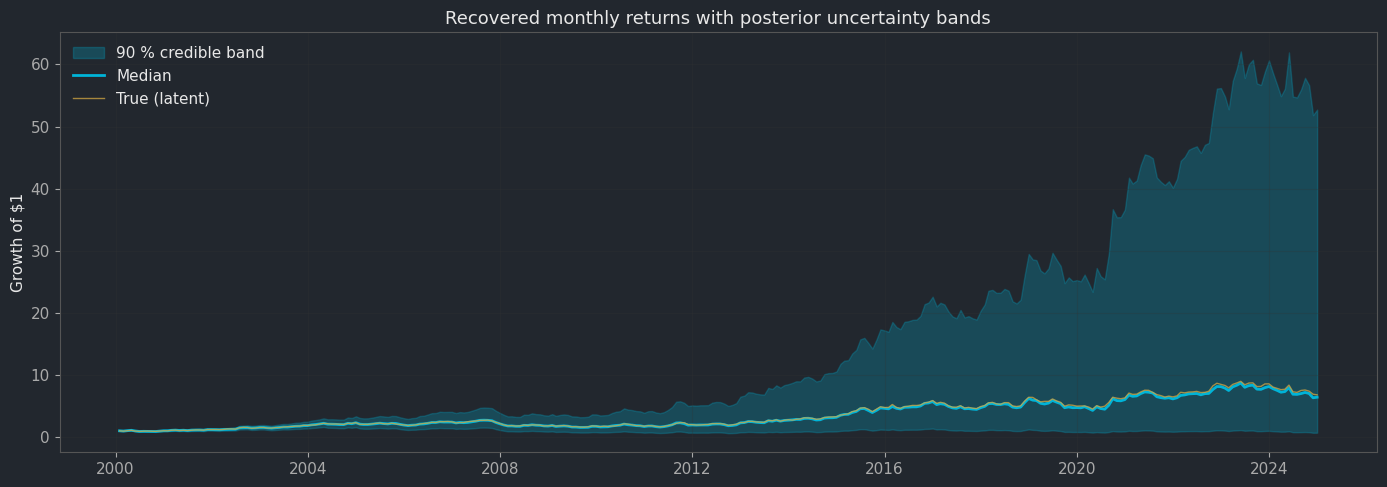

Posterior samples drawn:  80
Percentiles available:    [5, 25, 50, 75, 95]


In [17]:
uncertain_pipeline = FrequencyPipeline(
    returns=data['smoothed_quarterly'],
    factor_returns_monthly=data['factor_returns_monthly'],
    configs={'us_buyout': PE_PRESETS['us_large_buyout']},
    uncertainty_mode='full',
    uncertainty_n_samples=80,
    uncertainty_seed=7,
)
uncertain_result = uncertain_pipeline.run()

bands = uncertain_result.uncertainty_bands
median = bands.monthly[50]['us_buyout']
p5     = bands.monthly[5]['us_buyout']
p95    = bands.monthly[95]['us_buyout']

cum_median = (1 + median).cumprod()
cum_p5     = (1 + p5).cumprod()
cum_p95    = (1 + p95).cumprod()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(cum_p5.index, cum_p5, cum_p95, color=TEAL, alpha=0.25,
                label='90 % credible band')
ax.plot(cum_median.index, cum_median, color=TEAL, linewidth=2.0, label='Median')

cum_true = (1 + data['true_monthly']['us_buyout']).cumprod()
ax.plot(cum_true.index, cum_true, color=GOLD, linewidth=1.0, alpha=0.75,
        label='True (latent)')

ax.set_title('Recovered monthly returns with posterior uncertainty bands',
             fontsize=13)
ax.set_ylabel('Growth of $1')
ax.legend(frameon=False)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f'Posterior samples drawn:  {bands.n_samples}')
print(f'Percentiles available:    {sorted(bands.percentiles)}')

**How to use this in production**

- Build VaR / CVaR / drawdown numbers on the **5th** (or 95th) percentile band
  rather than the median, when the credible interval is wide.
- The width of the 5–95 band is the headline number for "how much does this
  output depend on the prior?"  When it's wide, your downstream risk number
  inherits that uncertainty.
- For threshold-AR(1) credit and NoSmoothing managed-futures, posterior
  sampling isn't yet wired — `uncertainty_bands` is `None` for those strategies
  and the warnings list explains why.

## Monte Carlo simulation

For VaR, CVaR, and stress scenarios the library exposes a Stage 4 simulator
(`DailySimulator`) that draws from the fitted residual distribution and
enforces the within-month aggregation constraint exactly.

We also include here a simpler **monthly bootstrap** — drawing N paths from
the disaggregated monthly residual, re-shuffled and re-combined with the
systematic factor path — which doesn't need daily factor data.

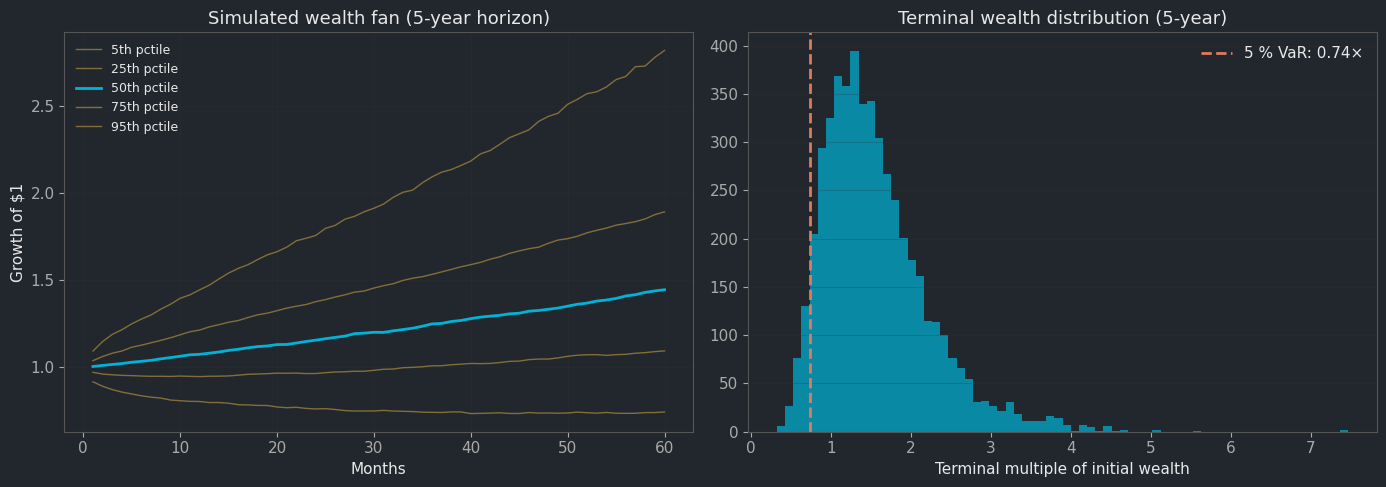

Median terminal wealth: 1.44×
5th percentile (VaR):   0.74×
95th percentile:        2.82×


In [18]:
# Monthly bootstrap from the recovered series
n_paths      = 5000
horizon_m    = 60
rng          = np.random.default_rng(42)
monthly      = result.monthly_returns['us_buyout'].to_numpy()
boot_idx     = rng.integers(0, len(monthly), size=(n_paths, horizon_m))
sim_paths    = monthly[boot_idx]                       # (n_paths, horizon_m)
cum_paths    = (1 + sim_paths).cumprod(axis=1)
terminal     = cum_paths[:, -1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

months = np.arange(1, horizon_m + 1)
percentiles = [5, 25, 50, 75, 95]
for p in percentiles:
    val = np.percentile(cum_paths, p, axis=0)
    axes[0].plot(months, val,
                 color=TEAL if p == 50 else GOLD,
                 linewidth=2.0 if p == 50 else 1.0,
                 alpha=1.0 if p == 50 else 0.55,
                 label=f'{p}th pctile')

axes[0].set_title('Simulated wealth fan (5-year horizon)', fontsize=13)
axes[0].set_xlabel('Months')
axes[0].set_ylabel('Growth of $1')
axes[0].legend(frameon=False, fontsize=9)
axes[0].grid(alpha=0.25)

axes[1].hist(terminal, bins=70, color=TEAL, alpha=0.7, edgecolor='none')
var95 = float(np.percentile(terminal, 5))
axes[1].axvline(var95, color=RED, linewidth=2.0, linestyle='--',
                label=f'5 % VaR: {var95:.2f}×')
axes[1].set_title('Terminal wealth distribution (5-year)', fontsize=13)
axes[1].set_xlabel('Terminal multiple of initial wealth')
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.25, axis='y')

plt.tight_layout()
plt.show()

print(f'Median terminal wealth: {np.median(terminal):.2f}×')
print(f'5th percentile (VaR):   {var95:.2f}×')
print(f'95th percentile:        {np.percentile(terminal, 95):.2f}×')

For a **fully calibrated** Stage 4 simulation that respects the within-month
aggregation constraint and uses the fitted residual distribution from Stage 2,
use `private_assets_frequency.daily.simulation.DailySimulator`.  The bootstrap
above is the simplest illustrative version — sufficient for monthly-horizon VaR
on a single-strategy synthetic example.

## Custom configuration — building your own preset

The shipped presets are starting points.  For a specific fund or index with
known characteristics, you'll customise the priors and factor model.

In [19]:
em_pe_config = AssetClassConfig(
    asset_class='private_equity',
    smoothing_model='ar1_bayesian',
    native_frequency='quarterly',
    preprocessing=None,
    lambda_prior=BetaDist(3, 2),
    beta_priors={
        'equity_market': NormalPrior(0.90, 0.40),
        'credit_spread': NormalPrior(0.30, 0.20),
    },
    alpha_prior=NormalPrior(0.02, 0.03),
    sigma_eps_prior=InverseGammaPrior(3.0, 0.02),
    default_factors=('MSCI_EM', 'EMBI'),
    public_proxy='MSCI Emerging Markets',
)

print('Available presets:\n')
for name, preset in {
    **PE_PRESETS, **HF_PRESETS, **CREDIT_PRESETS,
    **INFRA_PRESETS, **RE_PRESETS,
}.items():
    print(f'  {name:32s}  model={preset.smoothing_model:18s}  '
          f'freq={preset.native_frequency}')

Available presets:

  us_large_buyout                   model=ar1_bayesian        freq=quarterly
  us_early_venture                  model=ar1_bayesian        freq=quarterly
  us_late_venture                   model=ar1_bayesian        freq=quarterly
  us_mezzanine                      model=ar1_bayesian        freq=quarterly
  us_distressed                     model=ar1_bayesian        freq=quarterly
  europe_buyout                     model=ar1_bayesian        freq=quarterly
  europe_venture                    model=ar1_bayesian        freq=quarterly
  asia_buyout                       model=ar1_bayesian        freq=quarterly
  asia_venture                      model=ar1_bayesian        freq=quarterly
  equity_long_short                 model=ma_glm              freq=monthly
  global_macro                      model=ma_glm              freq=monthly
  event_driven                      model=ma_glm              freq=monthly
  relative_value                    model=ma_glm              

You can also start from a preset and selectively override fields — the
`with_overrides` helper returns a new immutable `AssetClassConfig`:

```python
my_buyout = PE_PRESETS['us_large_buyout'].with_overrides(
    lambda_prior=BetaDist(3, 2),
    alpha_prior=NormalPrior(0.01, 0.02),
)
```

## Sanity anchors & warnings

Every pipeline run accumulates inter-stage validation outcomes and (when
public proxies are supplied) sanity-anchor results.  Surface these to the
desk before signing off on the output.

In [20]:
print('=== Stage validations ===\n')
for v in result.stage_validations:
    icon = '✓' if v.passed else ('⚠️' if v.has_warnings else '✗')
    print(f'  {icon}  {v.stage}: {v.status.value}')

print('\n=== Pipeline warnings ===\n')
if result.warnings:
    for w in result.warnings:
        print(f'  ⚠️  {w}')
else:
    print('  ✓ No warnings.')

print('\n=== Sanity anchors ===\n')
if not any(result.sanity_anchors.values()):
    print('  (no public_proxies supplied — anchors not run)')
else:
    for strat_name, anchors in result.sanity_anchors.items():
        for name, anchor in anchors.items():
            icon = '✓' if anchor.passed else '⚠️'
            print(f'  {icon}  [{strat_name}]  {name}:  {anchor.message}')

=== Stage validations ===

  ✓  Stage 1 → 2 (volatility increase): pass
  ✓  Stage 2 → 3 (residual orthogonality): pass
  ✓  Stage 3 → 4 (round-trip aggregation): pass

=== Pipeline warnings ===

  ⚠️  [us_buyout/Stage1] β magnitude varies > 50% across the λ grid for factor(s) ['equity_market'] — λ and β are confounded; consider uncertainty_mode='full'.

=== Sanity anchors ===

  (no public_proxies supplied — anchors not run)


To enable sanity anchors, supply a `public_proxies` dict at pipeline construction
time:

```python
pipeline = FrequencyPipeline(
    ..., public_proxies={'us_buyout': monthly_russell_2000_returns},
)
```

Anchors check the desmoothed-vs-proxy volatility ratio, correlation, crisis-
window drawdown ratio, and beta band — all soft (warn-only) by default.

## Multiplicative vs additive aggregation

Always use multiplicative (the default).  The additive approximation drifts
~50+ bps per quarter for PE-magnitude returns; over multi-year horizons the
gap compounds.

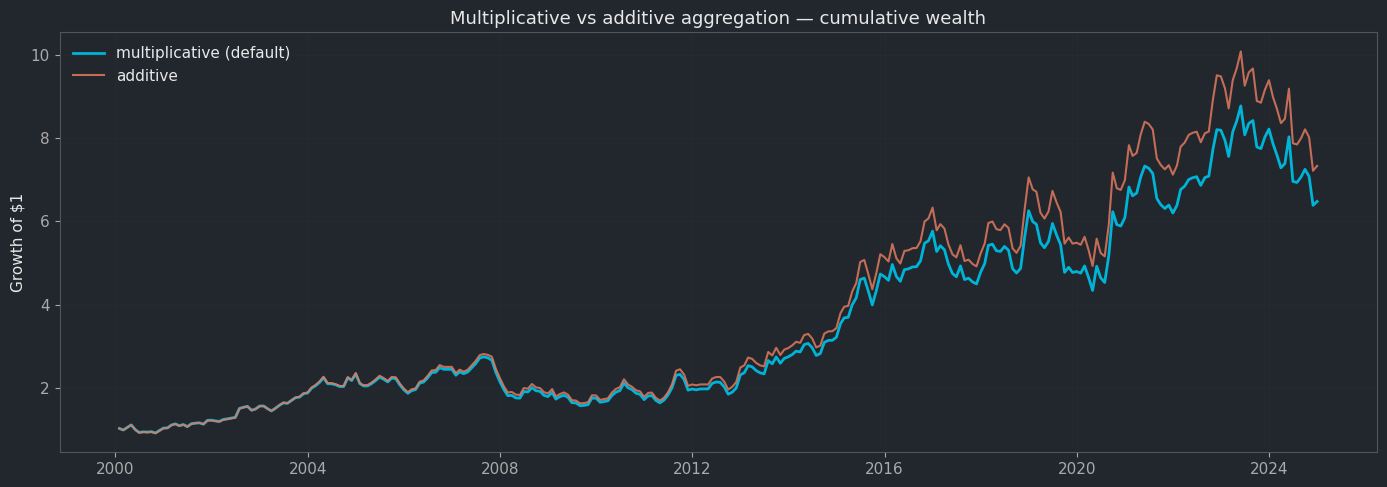

Largest single-month divergence: 93.3 bps  on 2024-06-30


In [21]:
add_pipeline = FrequencyPipeline(
    returns=data['smoothed_quarterly'],
    factor_returns_monthly=data['factor_returns_monthly'],
    configs={'us_buyout': PE_PRESETS['us_large_buyout']},
    aggregation_type='additive',
)
add_result = add_pipeline.run()
mult_result = result   # default multiplicative run

mult_monthly = mult_result.monthly_returns['us_buyout']
add_monthly  = add_result .monthly_returns['us_buyout']

# Cumulative growth contrast
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot((1 + mult_monthly).cumprod().index, (1 + mult_monthly).cumprod(),
        color=TEAL, linewidth=2.0, label='multiplicative (default)')
ax.plot((1 + add_monthly).cumprod().index, (1 + add_monthly).cumprod(),
        color=RED,  linewidth=1.5, alpha=0.85, label='additive')
ax.set_title('Multiplicative vs additive aggregation — cumulative wealth',
             fontsize=13)
ax.set_ylabel('Growth of $1')
ax.legend(frameon=False)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Largest divergence — typically a crisis quarter
diff_monthly = (mult_monthly - add_monthly).abs()
worst = diff_monthly.idxmax()
print(f'Largest single-month divergence: '
      f'{diff_monthly.max() * 1e4:.1f} bps  on {worst.date()}')

## Production tips & common pitfalls

### Do ✓

- **Always check `result.warnings` before using outputs.**  A flat λ posterior
  means your monthly returns are prior-driven, not data-driven.
- **Use `uncertainty_mode='full'` for any risk number that goes downstream.**
  Point estimates create false precision.  A 90 % CI of ±30 % around the
  recovered σ is realistic for short PE histories.
- **Validate round-trip aggregation.**  The Stage 3 → 4 gate already does this
  at 1e-10; copy-paste the manual verification cell when integrating into your
  own workflows.
- **Default to multiplicative aggregation.**  Always.  The additive
  approximation is only acceptable for very small returns.
- **Choose priors carefully.**  The β prior should reflect economic reality —
  leverage for buyouts, duration for infrastructure, credit quality for
  mezzanine.  Wrong priors with short history → wrong outputs.

### Don't ✗

- **Don't use raw quarterly PE returns for risk models.**  Raw σ understates
  by ~60 %, raw correlation by ~30 %.
- **Don't skip Stage 1 (desmoothing).**  Garbage in, garbage out — Chow-Lin on
  smoothed data produces smoother monthly data.
- **Don't over-interpret the daily Kalman path (Stage 4 Mode A).**  It's a
  conditional expectation, not a realisation.
- **Don't assume stationarity.**  If the strategy's leverage or style has
  changed materially, full-sample β is an average, not the current exposure.
- **Don't ignore carry/MTM for credit.**  Desmoothing the carry creates fake
  volatility.

### When results look wrong

1. λ posterior flat?  Data is uninformative.  Output is prior-driven.
2. Factor R² very low?  Missing systematic factors.
3. Desmoothed σ > 3× public proxy σ?  Over-desmoothing — λ is too high.
4. Cross-strategy correlation > 0.95?  Everything has collapsed onto the equity
   factor — your factor model isn't separating the strategies.
5. Run with `fallback_policy='strict'` to surface every warning as an
   exception.

## Next steps

- **Bring your own data.**  Replace the synthetic generators with your real
  PE / HF / credit indices and the corresponding Barra (or similar) factor
  returns.  The API surface is identical.
- **Custom factor models.**  Add factors beyond equity / credit — sector,
  size, value, momentum, geography.  More factors = better decomposition =
  better disaggregation.
- **Daily extension.**  Provide `factor_returns_daily` to get a Stage 4 daily
  series (Kalman Mode A) or a Monte Carlo simulator (Mode B).
- **Methodology references.**
  - Geltner (1993) — original AR(1) appraisal smoothing.
  - Getmansky, Lo & Makarov (2004) — MA(q) for hedge funds.
  - Chow & Lin (1971), Fernández (1981), Litterman (1983) — temporal
    disaggregation.
  - Hansen (1994) — skewed-t distribution for residuals.
  - MSCI (2025) — Private Equity Factor Model methodology.